In [1]:
import numpy as np
import pandas as pd
import json
from collections import Counter
from pathlib import Path

# ── Bloco 3 · UPGMA e PAM para k = 1 … 10, as três curvas e o dendrograma ──
import subprocess
from math import comb
from scipy.cluster.hierarchy import linkage, cophenet, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

In [2]:
# 1a. Os cinco caracteres, com resíduo = carácter ausente (None). Os 6 com resíduo de FUNÇÃO
#     vão direto para a família de resíduos e ficam fora do agrupamento (regra D3).
EIXOS = ['funcao', 'motor', 'regime', 'surrogate', 'medicao']
PESOS = {'funcao': 0.40, 'motor': 0.30, 'regime': 0.10, 'surrogate': 0.10, 'medicao': 0.10} # D1 (rank-sum)


########## Árvores Funcao Incerteza
ATITUDE  = {'OV':'oportunidade',
            'OM':'oportunidade',
            'OL':'oportunidade',
            'AV':'ameaça',
            'AM':'ameaça',
            'AR':'ameaça'}

OBJETO   = {'OV':'valor',     'AV':'valor',
            'OM':'modelo',    'AM':'modelo',
            'OL':'próprio-OL','AR':'próprio-AR'}


########## Árvores Motor Otimizacao
PARADIGMA= {'EA-Dominância':         'EA',
            'EA-Decomposição':       'EA',
            'EA-Indicador':          'EA',
            'BO-Melhoria-de-Pareto': 'BO',
            'BO-Decomposição':       'BO',
            'BO-Hipervolume':        'BO',
            'BO-Especiais':          'BO'}

PRINCIPIO= { # par espelhado 1
            'EA-Dominância'         : 'dominância',
            'BO-Melhoria-de-Pareto' : 'dominância',
             # par espelhado 2
            'EA-Decomposição'       : 'decomposição',
            'BO-Decomposição'       : 'decomposição',
             # par espelhado 3
            'EA-Indicador'          : 'indicador',
            'BO-Hipervolume'        : 'indicador',     
             # sem espelho
            'BO-Especiais'          : 'especiais'}


########## Árvore Surrogate
TIPO_SUR = {'GP':'regressor',
            'RG':'regressor',
            'NN':'regressor',
            'CL':'classificador'}


########## Árvore Medicao Incerteza
FONTE4   = {'VA': 'analítica', 
            'VN': 'nativa', 
            'DE': 'exógena', 
            'EE': 'exógena', 
            'DG': 'exógena'}

In [3]:
########### Função de visualização
sns.set_theme(style="white", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "axes.titleweight": "bold",
                     "axes.titlesize": 13, "font.size": 11, "axes.titlepad": 12,
                     "axes.edgecolor": "#cfcfcf", "axes.linewidth": 0.6})
GREENS = LinearSegmentedColormap.from_list(
    "GreensTrunc", plt.get_cmap("Greens")(np.linspace(0.12, 0.95, 256)))
BASE_FS = 9

def _ordem(d, col):
    """Categorias por frequência decrescente, com o resíduo sempre no fim."""
    cats = list(d[col].value_counts().index)
    res = [c for c in cats if str(c).lower().startswith("res")]
    return [c for c in cats if c not in res] + res

def _trim(s, n=24):
    s = str(s)
    return s if len(s) <= n else s[:n-1] + "…"

def heatmap_2d(df, linhas, colunas, vmax=50, figsize=(7.0, 6.0), rot_x=35,
               escala_fonte=1.3, titulo=None, salvar_em=None,
               ordem_linhas=None, ordem_colunas=None, ax=None, trim=24):
    """
    linhas  : coluna da base no eixo Y
    colunas : coluna da base no eixo X
    vmax    : teto da escala de cor (None = máximo observado)
    ax      : eixo pronto (para compor vários painéis numa figura); None = cria a própria figura
    trim    : tamanho máximo dos rótulos
    Devolve a tabela de contingência.
    """
    d = df.copy()
    ct = (pd.crosstab(d[linhas], d[colunas])
            .reindex(index=ordem_linhas or _ordem(d, linhas),
                     columns=ordem_colunas or _ordem(d, colunas), fill_value=0).astype(int))

    fig, ax = plt.subplots(figsize=figsize) if ax is None else (ax.figure, ax)
    ax.set_facecolor("white")
    sns.heatmap(ct, ax=ax, cmap=GREENS, mask=(ct == 0),
                annot=ct.astype(str).where(ct > 0, ""), fmt="",
                linewidths=0, cbar=False, vmax=vmax,
                xticklabels=[_trim(c, trim) for c in ct.columns],
                yticklabels=[_trim(i, trim) for i in ct.index],
                annot_kws={"fontsize": BASE_FS * 1.65})

    # célula de valor 1 fica 50% mais clara, para não competir com as demais
    mesh = ax.collections[0]
    fc = np.array(mesh.get_facecolors(), dtype=float)
    for k, v in enumerate(ct.values.ravel()):
        if v == 1:
            r, g, b, a = fc[k]
            fc[k] = [r + (1-r)*.5, g + (1-g)*.5, b + (1-b)*.5, a]
    mesh.set_facecolors(fc); mesh.set_array(None)

    ax.grid(False); ax.set_xlabel(""); ax.set_ylabel("")
    if titulo: ax.set_title(titulo)
    plt.setp(ax.get_xticklabels(), rotation=rot_x, ha="right" if rot_x else "center")
    plt.setp(ax.get_yticklabels(), rotation=0)
    for t in [*ax.get_xticklabels(), *ax.get_yticklabels()]:
        t.set_fontsize(t.get_fontsize() * escala_fonte)

    fig.tight_layout()
    if salvar_em: fig.savefig(salvar_em, bbox_inches="tight")
    return ct

In [4]:
def caracter(v, eixo):
    x = v[eixo]
    return None if x.startswith('Res') else x

## Leitura e preparacao dos Dados

In [5]:
### Leitura de dados
MESTRADO = Path('/Users/gmello/Documents/python_repos/mestrado')
base = json.load(open(MESTRADO / 'dissertacao/SPEC/bases/base127.json', encoding='utf-8'))
ids = sorted(base)

### Convete em dataframe
df = pd.DataFrame({e: [caracter(base[i], e) for i in ids] for e in EIXOS}, index=ids)
df.insert(0, 'acronimo', [base[i]['acronimo'][:24] for i in ids])
df = df.reset_index().rename(columns={'index': 'id'})

print(df.shape)
df.head()

(127, 7)


,id,acronimo,funcao,motor,regime,surrogate,medicao
0,b1,ParEGO,OV,BO-Decomposição,online,GP,VA
1,b13,AdaMoR-DDMOEA,AM,EA-Decomposição,offline,NN,EE
2,b14,SA²-MOEA,OM,EA-Dominância,online,RG,DE
3,b15,U-RankMOEA,OV,BO-Especiais,online,GP,DE
4,b2,MOEA/D-EGO,OV,BO-Decomposição,online,GP,VA


In [6]:
### Calcula Macro Agrupamentos
df['atitude_funcao']   = df['funcao'].map(ATITUDE)     # oportunidade · ameaça
df['objeto_funcao']    = df['funcao'].map(OBJETO)      # valor · modelo · próprio-OL · próprio-AR
df['paradigma_motor']  = df['motor'].map(PARADIGMA)    # BO · EA
df['principio_motor']  = df['motor'].map(PRINCIPIO)    # dominância · decomposição · indicador · especiais
df['tipo_surrogate']   = df['surrogate'].map(TIPO_SUR) # regressor · classificador
df['fonte_incerteza4'] = df['medicao'].map(FONTE4)     # os quatro níveis da tabela do D9 (NaN = resíduo de medição)
df['fonte_incerteza']  = np.where(df['medicao'].isna(),  'fabricada', # os dois níveis do Bloco 4: analítica × fabricada
                         np.where(df['medicao'] == 'VA', 'analítica', 'fabricada'))

print(df.shape)
df.head()

(127, 14)


,id,acronimo,funcao,motor,regime,surrogate,medicao,atitude_funcao,objeto_funcao,paradigma_motor,principio_motor,tipo_surrogate,fonte_incerteza4,fonte_incerteza
0,b1,ParEGO,OV,BO-Decomposição,online,GP,VA,oportunidade,valor,BO,decomposição,regressor,analítica,analítica
1,b13,AdaMoR-DDMOEA,AM,EA-Decomposição,offline,NN,EE,ameaça,modelo,EA,decomposição,regressor,exógena,fabricada
2,b14,SA²-MOEA,OM,EA-Dominância,online,RG,DE,oportunidade,modelo,EA,dominância,regressor,exógena,fabricada
3,b15,U-RankMOEA,OV,BO-Especiais,online,GP,DE,oportunidade,valor,BO,especiais,regressor,exógena,fabricada
4,b2,MOEA/D-EGO,OV,BO-Decomposição,online,GP,VA,oportunidade,valor,BO,decomposição,regressor,analítica,analítica


## [F1] Familias teóricas / naive

In [7]:
keys_teoricas = ['atitude_funcao', 'paradigma_motor', 'fonte_incerteza']

dp_familias_teoricas = df.groupby(keys_teoricas, dropna=True).size().sort_values(ascending=False).reset_index(name = 'algoritmos')
dp_familias_teoricas['familia_teorica'] = (dp_familias_teoricas['paradigma_motor'] + '_' + 
                                           dp_familias_teoricas['atitude_funcao'] + '_' + 
                                           dp_familias_teoricas['fonte_incerteza'])
dp_familias_teoricas

,atitude_funcao,paradigma_motor,fonte_incerteza,algoritmos,familia_teorica
0,oportunidade,BO,analítica,59,BO_oportunidade_analítica
1,ameaça,EA,fabricada,13,EA_ameaça_fabricada
2,oportunidade,EA,analítica,13,EA_oportunidade_analítica
3,ameaça,EA,analítica,11,EA_ameaça_analítica
4,oportunidade,BO,fabricada,8,BO_oportunidade_fabricada
5,oportunidade,EA,fabricada,7,EA_oportunidade_fabricada
6,ameaça,BO,analítica,4,BO_ameaça_analítica


In [8]:
df2 = df.merge(dp_familias_teoricas[keys_teoricas + ['familia_teorica']], 
               on = keys_teoricas, 
               how = 'left')

print(df2['familia_teorica'].isna().mean())

df2['familia_teorica'] = df2['familia_teorica'].fillna('residuo')
df2

0.09448818897637795


,id,acronimo,funcao,motor,regime,surrogate,medicao,atitude_funcao,objeto_funcao,paradigma_motor,principio_motor,tipo_surrogate,fonte_incerteza4,fonte_incerteza,familia_teorica
0,b1,ParEGO,OV,BO-Decomposição,online,GP,VA,oportunidade,valor,BO,decomposição,regressor,analítica,analítica,BO_oportunidade_analítica
1,b13,AdaMoR-DDMOEA,AM,EA-Decomposição,offline,NN,EE,ameaça,modelo,EA,decomposição,regressor,exógena,fabricada,EA_ameaça_fabricada
2,b14,SA²-MOEA,OM,EA-Dominância,online,RG,DE,oportunidade,modelo,EA,dominância,regressor,exógena,fabricada,EA_oportunidade_fabricada
3,b15,U-RankMOEA,OV,BO-Especiais,online,GP,DE,oportunidade,valor,BO,especiais,regressor,exógena,fabricada,BO_oportunidade_fabricada
4,b2,MOEA/D-EGO,OV,BO-Decomposição,online,GP,VA,oportunidade,valor,BO,decomposição,regressor,analítica,analítica,BO_oportunidade_analítica
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,o56,ε-PoHVI,OV,BO-Hipervolume,online,GP,VA,oportunidade,valor,BO,indicador,regressor,analítica,analítica,BO_oportunidade_analítica
123,o6,KEMOCO,OV,BO-Hipervolume,online,GP,VA,oportunidade,valor,BO,indicador,regressor,analítica,analítica,BO_oportunidade_analítica
124,pp6,AB-MOEA,AV,EA-Decomposição,online,GP,VA,ameaça,valor,EA,decomposição,regressor,analítica,analítica,EA_ameaça_analítica
125,wang4,SA-NSGA-II,AM,EA-Dominância,offline,None,EE,ameaça,modelo,EA,dominância,NaN,exógena,fabricada,EA_ameaça_fabricada


## [F2] Famílias agrupamento hierárquico

#### Funcoes para calculo de distancia entre 2 algoritmos no espaço de eixos taxonômicos

In [9]:
def d_ramo_classe(a, b, ramo, classe):
    """Regra comum a função e motor: 0 igual · 1/3 mesmo ramo · 2/3 ramos diferentes, classes espelhadas · 1 tudo diferente."""
    if a == b:                 return 0.0
    if ramo[a] == ramo[b]:     return 1/3
    if classe[a] == classe[b]: return 2/3
    return 1.0

def d_funcao(a, b):    return d_ramo_classe(a, b, ATITUDE, OBJETO)
def d_motor(a, b):     return d_ramo_classe(a, b, PARADIGMA, PRINCIPIO)
def d_surrogate(a, b):
    if a == b: return 0.0
    return 0.5 if TIPO_SUR[a] == TIPO_SUR[b] == 'regressor' else 1.0
def d_medicao(a, b):   return 0.0 if a == b else 1.0
def d_regime(a, b):    return 0.0 if a == b else 1.0

In [10]:
### Distância entre dois estudos: Gower ponderado sobre as árvores dos eixos (D1 + D2 + D3)
D_EIXO = {'funcao': d_funcao, 'motor': d_motor, 'regime': d_regime, 'surrogate': d_surrogate, 'medicao': d_medicao}
dfi = df.set_index('id')                                   # o mesmo df, indexado por id, só para consulta por estudo

def gower(i, j, pesos=PESOS):
    ''' Funcao que calcula a distancia taxonomica entre 2 algoritmos de id's i e j'''
    num = den = 0.0
    for e, w in pesos.items():
        a, b = dfi.at[i, e], dfi.at[j, e] # busca da tabela os valores das categorias do eixo "e" (funcao/motor/regime/...) avaliado no momento para os algoritmos de ids "i" e "j"
        if pd.isna(a) or pd.isna(b):      # carácter ausente (resíduo) sai da conta — D3
            continue
        num += w * D_EIXO[e](a, b)  # usa a funcao de distancia (dict D_EIXO) para o eixo "e" sobre as categorias a e b (valores de "e" para algoritmos "i" e "j")
        den += w                    # pondera a distancia pelo peso de importancia do eixo "e"
    return num / den

#### Calculo de distancias taxonômicas entre todos os algoritmos do corpus

In [11]:
### Matriz de distâncias 127 × 127
matriz = np.zeros((len(ids), len(ids)))
for p, i in enumerate(ids):
    for q in range(p + 1, len(ids)):
        matriz[p, q] = matriz[q, p] = gower(i, ids[q])
df_distancias = pd.DataFrame(matriz, index=ids, columns=ids)

print(df_distancias.shape)
df_distancias.head()

(127, 127)


,b1,b13,b14,b15,b2,b3,b4,b5,b7,b8,...,mtm4,mtm5,mtm6,mtm7,o23,o56,o6,pp6,wang4,wang5
b1,0.000000,0.850000,0.583333,0.200000,0.000000,0.333333,0.900000,0.700000,0.740741,0.433333,...,0.300000,0.300000,0.100000,0.100000,0.000000,0.100000,0.100000,0.466667,1.000000,0.450000
b13,0.850000,0.000000,0.616667,0.950000,0.850000,0.516667,0.300000,0.283333,0.314815,0.616667,...,0.750000,0.750000,0.950000,0.950000,0.750000,0.950000,0.950000,0.383333,0.111111,0.650000
b14,0.583333,0.616667,0.000000,0.483333,0.583333,0.250000,0.466667,0.750000,0.611111,0.250000,...,0.283333,0.383333,0.583333,0.583333,0.750000,0.583333,0.583333,0.650000,0.518519,0.233333
b15,0.200000,0.950000,0.483333,0.000000,0.200000,0.533333,0.900000,0.900000,0.740741,0.533333,...,0.400000,0.400000,0.200000,0.200000,0.333333,0.200000,0.200000,0.666667,1.000000,0.450000
b2,0.000000,0.850000,0.583333,0.200000,0.000000,0.333333,0.900000,0.700000,0.740741,0.433333,...,0.300000,0.300000,0.100000,0.100000,0.000000,0.100000,0.100000,0.466667,1.000000,0.450000


In [12]:
### Quem entra no agrupamento: os 121 de função nomeada (os 6 de resíduo de função vão direto à família de resíduos — D3)
nomeados = df.loc[df['funcao'].notna(), 'id'].tolist()
df_dist_nomeados = df_distancias.loc[nomeados, nomeados]
D = df_dist_nomeados.values                                # a mesma matriz em numpy, para as funções de medida

print(len(nomeados), df_dist_nomeados.shape)               # 121 (121, 121)

121 (121, 121)


#### Funções de Agrupamento hierárquico aglomerativo com ligação média — UPGMA (Sokal & Michener, 1958)

In [13]:
def cortar(Z, k):
    """Agrupamento hierarquico / partição em k grupos: executa as primeiras n-k junções de Z.
    Devolve os rótulos (0 … k-1) e se o corte é LIMPO — a última junção feita está estritamente
    abaixo da próxima; se as duas têm a mesma altura, a partição em k não é única (empate)."""
    n = Z.shape[0] + 1
    pai = list(range(2 * n - 1))
    def raiz(x):
        while pai[x] != x:
            pai[x] = pai[pai[x]]; x = pai[x]
        return x
    for m in range(n - k):
        pai[raiz(int(Z[m, 0]))] = n + m
        pai[raiz(int(Z[m, 1]))] = n + m
    raizes = [raiz(i) for i in range(n)]
    ordem = {r: j for j, r in enumerate(dict.fromkeys(raizes))}
    rot = np.array([ordem[r] for r in raizes])
    limpo = k in (1, n) or (Z[n - k - 1, 2] < Z[n - k, 2] - 1e-12)
    return rot, limpo


def rotulos_por_tamanho(rot):
    """Renumera as famílias de 1 a k, da maior para a menor (1 = a maior)."""
    ordem = pd.Series(rot).value_counts().index.tolist()
    return np.array([ordem.index(r) + 1 for r in rot])

In [14]:
#### Metricas de avaliação de clusterizacao: distância média dentro das famílias, silhueta e concordância (ARI)
def dist_intra(D, rot):
    iu = np.triu_indices(len(rot), 1)
    mesmo = rot[iu[0]] == rot[iu[1]]
    return D[iu][mesmo].mean() if mesmo.any() else np.nan

def silhueta(D, rot):
    """s(i) = (b - a) / max(a, b): a = distância média aos da própria família, b = a menor distância média
    a outra família. Membro único → 0, por convenção."""
    s = np.zeros(len(rot))
    for i in range(len(rot)):
        mesmo = rot == rot[i]; mesmo[i] = False
        if not mesmo.any(): continue
        a = D[i, mesmo].mean()
        b = min(D[i, rot == g].mean() for g in np.unique(rot) if g != rot[i])
        s[i] = (b - a) / max(a, b) if max(a, b) > 0 else 0.0
    return s

In [15]:
### Leitura de uma partição: tamanho, algoritmo-tipo e composição de cada família
def tipo_da_familia(membros):
    """O medoide da família (menor distância média aos demais), escolhido entre os de perfil completo —
    um estudo com carácter ausente não pode diferir nele e ficaria central por artefato."""
    completos = [m for m in membros if dfi.loc[m, EIXOS].notna().all()] or membros
    return df_dist_nomeados.loc[completos, membros].mean(axis=1).idxmin()

def resumo_particao(df3, col):
    linhas = []
    for fam, g in df3[df3[col] > 0].groupby(col):
        membros = g['id'].tolist()
        linhas.append({'familia': fam, 'n': len(membros), 'tipo': dfi.at[tipo_da_familia(membros), 'acronimo'],
                       'atitude':   dict(g['atitude_funcao'].value_counts()),
                       'paradigma': dict(g['paradigma_motor'].value_counts(dropna=False)),
                       'fonte':     dict(g['fonte_incerteza'].value_counts(dropna=False)),
                       'regime':    dict(g['regime'].value_counts()),
                       'membros':   ', '.join(g['acronimo'].str[:14])})
    return pd.DataFrame(linhas).set_index('familia')

#### Agrupamento hierárquico aglomerativo com ligação média — UPGMA (Sokal & Michener, 1958)

In [16]:
# o scipy recebe a metade superior da matriz como vetor (squareform); Z guarda as 120 junções:
# quem juntou com quem, a que altura (distância média entre os dois grupos) e quantos membros o grupo novo tem
vetor = squareform(D, checks=False)
Z = linkage(vetor, method='average')
cofenetica, _ = cophenet(Z, vetor)                         # fidelidade do dendrograma à matriz

print(f'correlação cofenética: {cofenetica:.3f}')          # esperado: 0.893

correlação cofenética: 0.893


In [17]:
### Calcula agrupamento hierarquico para k = 1 … 10: uma coluna por k, mais as curvas
df_familias_hier = pd.DataFrame({'id': nomeados})

linhas = []
for k in range(1, 11):
    rot, limpo = cortar(Z, k)
    rot = rotulos_por_tamanho(rot)
    df_familias_hier[f'fam_k{k}'] = rot
    tamanhos = df_familias_hier[f'fam_k{k}'].value_counts().tolist()
    linhas.append({'k': k, 'corte_limpo': limpo,
                   'dist_intra': dist_intra(D, rot),
                   'silhueta': silhueta(D, rot).mean() if k > 1 else np.nan,
                   'menor_familia': min(tamanhos), 'tamanhos': tamanhos})

# Resumo de metricas por k
dp_curvas_hier = pd.DataFrame(linhas).set_index('k')
dp_curvas_hier

,corte_limpo,dist_intra,silhueta,menor_familia,tamanhos
k,,,,,
1,True,0.416963,NaN,121,[121]
2,True,0.251830,0.598752,30,"[91, 30]"
3,True,0.246094,0.463727,4,"[91, 26, 4]"
4,True,0.159562,0.558301,4,"[70, 26, 21, 4]"
5,True,0.157430,0.531691,1,"[70, 25, 21, 4, 1]"
6,True,0.148220,0.539591,1,"[70, 21, 18, 7, 4, 1]"
7,True,0.142827,0.571912,1,"[70, 21, 12, 7, 6, 4, 1]"
8,True,0.137523,0.545220,1,"[70, 14, 12, 7, 7, 6, 4, 1]"
9,True,0.136433,0.549568,1,"[70, 14, 10, 7, 7, 6, 4, 2, 1]"


In [18]:
df_familias_hier.head()

,id,fam_k1,fam_k2,fam_k3,fam_k4,fam_k5,fam_k6,fam_k7,fam_k8,fam_k9,fam_k10
0,b1,1,1,1,1,1,1,1,1,1,1
1,b13,1,2,2,2,2,4,4,4,4,4
2,b14,1,1,1,3,3,2,2,5,5,5
3,b15,1,1,1,1,1,1,1,1,1,1
4,b2,1,1,1,1,1,1,1,1,1,1


In [19]:
### Junta ao df2: os 6 de resíduo de função ficam com 0 (família de resíduos)
df3 = df2.merge(df_familias_hier, on='id', how='left')
cols_k = [c for c in df3.columns if c.startswith('fam_k')]
df3[cols_k] = df3[cols_k].fillna(0).astype(int)

print(df3.shape)
df3.head()

(127, 25)


,id,acronimo,funcao,motor,regime,surrogate,medicao,atitude_funcao,objeto_funcao,paradigma_motor,...,fam_k1,fam_k2,fam_k3,fam_k4,fam_k5,fam_k6,fam_k7,fam_k8,fam_k9,fam_k10
0,b1,ParEGO,OV,BO-Decomposição,online,GP,VA,oportunidade,valor,BO,...,1,1,1,1,1,1,1,1,1,1
1,b13,AdaMoR-DDMOEA,AM,EA-Decomposição,offline,NN,EE,ameaça,modelo,EA,...,1,2,2,2,2,4,4,4,4,4
2,b14,SA²-MOEA,OM,EA-Dominância,online,RG,DE,oportunidade,modelo,EA,...,1,1,1,3,3,2,2,5,5,5
3,b15,U-RankMOEA,OV,BO-Especiais,online,GP,DE,oportunidade,valor,BO,...,1,1,1,1,1,1,1,1,1,1
4,b2,MOEA/D-EGO,OV,BO-Decomposição,online,GP,VA,oportunidade,valor,BO,...,1,1,1,1,1,1,1,1,1,1


#### Análise agrupamento hierárquico

In [20]:
pd.set_option('display.max_colwidth', 160)
resumo_particao(df3, 'fam_k4')

,n,tipo,atitude,paradigma,fonte,regime,membros
familia,,,,,,,
1,70,qEHVI,{'oportunidade': 70},"{'BO': 67, nan: 3}","{'analítica': 60, 'fabricada': 10}",{'online': 70},"ParEGO, U-RankMOEA, MOEA/D-EGO, USeMO, BS-MOBO, qEHVI, SMS-EGO, EMMI (EMmI), MS-VHGP-EIHV, AdaE-SAEA, EPBII / EIPBII, MORBO, PPESMOC, LBN-MOBO, JES, FoMEMO,..."
2,26,K-MOGA,{'ameaça': 26},"{'EA': 24, nan: 2}","{'fabricada': 14, 'analítica': 12}","{'online': 15, 'offline': 11}","AdaMoR-DDMOEA, CSEA, Prob-RVEA / Pr, DR (Dual-Ranki, θ-DEA-DP, DDMOEA/GAN, MMRAEA, PC-SAEA, K-MOGA, IBE-CSEA, PD-MOEA, UA-DBO, SABBa, PAL-SAPSO, UA-MORL-Dif..."
3,21,AK-MORO,{'oportunidade': 21},"{'EA': 20, nan: 1}","{'analítica': 14, 'fabricada': 7}","{'online': 20, 'offline': 1}","SA²-MOEA, K-RVEA, KTA2, SP-RV-MOEANet, DTK-MODE, EMMOEA, SAMOEA-TL2M, EHVIMOPSO, AK-MORO, KAEA-C, SK-MORS, EDN-ARMOEA, CLMEA, HET-EMO (HET-N, NSGAIII-EHVI, ..."
4,4,RVMM,{'ameaça': 4},{'BO': 4},{'analítica': 4},"{'online': 3, 'offline': 1}","GCS-MOE, GP-DGS, RVMM, ATKIS"


In [21]:
resumo_particao(df3, 'fam_k7')

,n,tipo,atitude,paradigma,fonte,regime,membros
familia,,,,,,,
1,70,qEHVI,{'oportunidade': 70},"{'BO': 67, nan: 3}","{'analítica': 60, 'fabricada': 10}",{'online': 70},"ParEGO, U-RankMOEA, MOEA/D-EGO, USeMO, BS-MOBO, qEHVI, SMS-EGO, EMMI (EMmI), MS-VHGP-EIHV, AdaE-SAEA, EPBII / EIPBII, MORBO, PPESMOC, LBN-MOBO, JES, FoMEMO,..."
2,21,AK-MORO,{'oportunidade': 21},"{'EA': 20, nan: 1}","{'analítica': 14, 'fabricada': 7}","{'online': 20, 'offline': 1}","SA²-MOEA, K-RVEA, KTA2, SP-RV-MOEANet, DTK-MODE, EMMOEA, SAMOEA-TL2M, EHVIMOPSO, AK-MORO, KAEA-C, SK-MORS, EDN-ARMOEA, CLMEA, HET-EMO (HET-N, NSGAIII-EHVI, ..."
3,12,PAL-SAPSO,{'ameaça': 12},"{'EA': 11, nan: 1}",{'analítica': 12},"{'online': 8, 'offline': 4}","Prob-RVEA / Pr, K-MOGA, PD-MOEA, SABBa, PAL-SAPSO, TC-SAEA, IBEA-MS, SBP-BO, SA-MOPSO (PPD), CK-MOGA, UA-IBEA (sigla, AB-MOEA"
4,7,CSEA,{'ameaça': 7},{'EA': 7},{'fabricada': 7},"{'online': 5, 'offline': 2}","AdaMoR-DDMOEA, CSEA, PC-SAEA, IBE-CSEA, TR-NSGA-II, GS-MOMA / GSM , SA-NSGA-II"
5,6,UA-DBO,{'ameaça': 6},"{'EA': 5, nan: 1}",{'fabricada': 6},"{'offline': 5, 'online': 1}","DR (Dual-Ranki, DDMOEA/GAN, MMRAEA, UA-DBO, UA-MORL-Diff, PIO"
6,4,RVMM,{'ameaça': 4},{'BO': 4},{'analítica': 4},"{'online': 3, 'offline': 1}","GCS-MOE, GP-DGS, RVMM, ATKIS"
7,1,θ-DEA-DP,{'ameaça': 1},{'EA': 1},{'fabricada': 1},{'online': 1},θ-DEA-DP


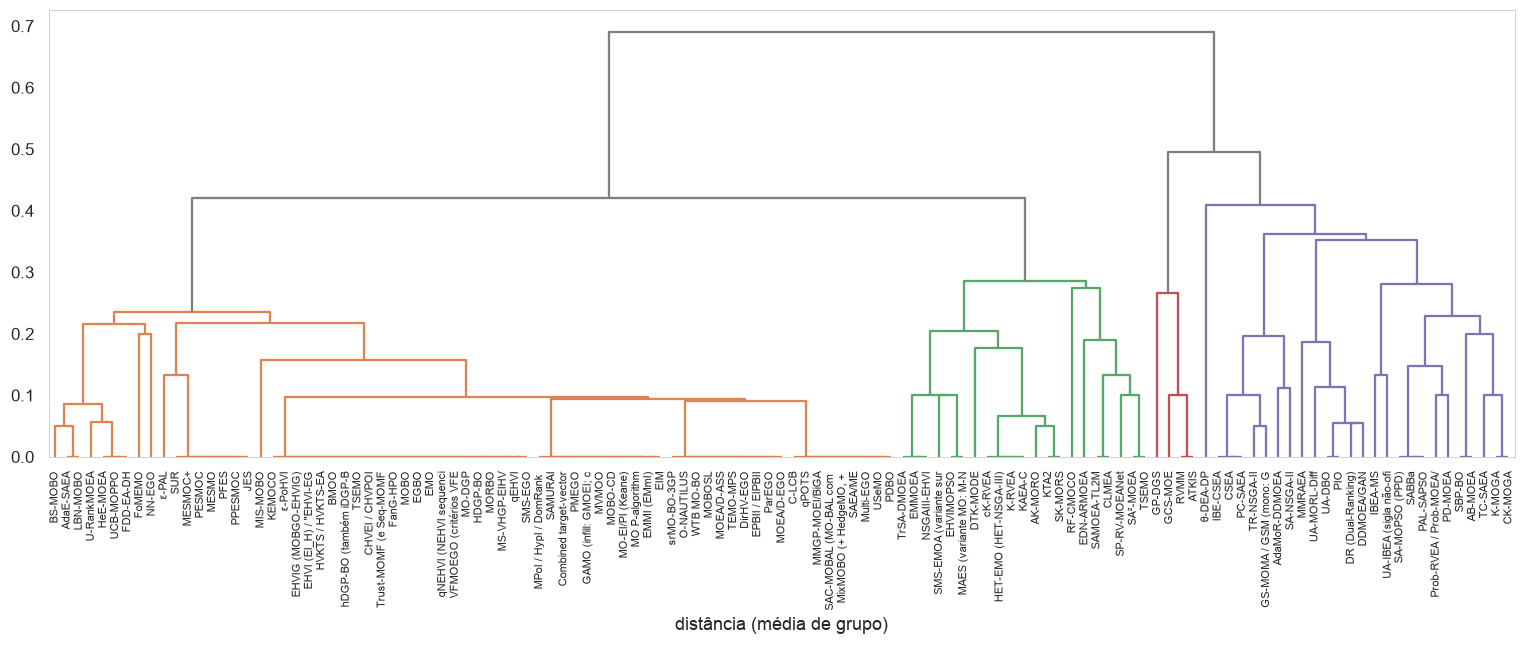

In [22]:
### Dendrograma inteiro (leitura de trabalho; a figura da seção vem depois, com nomes de exibição)
fig, ax = plt.subplots(figsize=(14, 6))
k = 4
dendrogram(Z, labels=dfi.loc[nomeados, 'acronimo'].str[:22].tolist(), orientation='top', leaf_font_size=7, ax=ax,
           color_threshold=(Z[-k, 2] + Z[-k + 1, 2]) / 2, above_threshold_color='grey')
ax.set_xlabel('distância (média de grupo)')
plt.tight_layout(); plt.show()

52 perfis únicos · correlação cofenética: 0.814


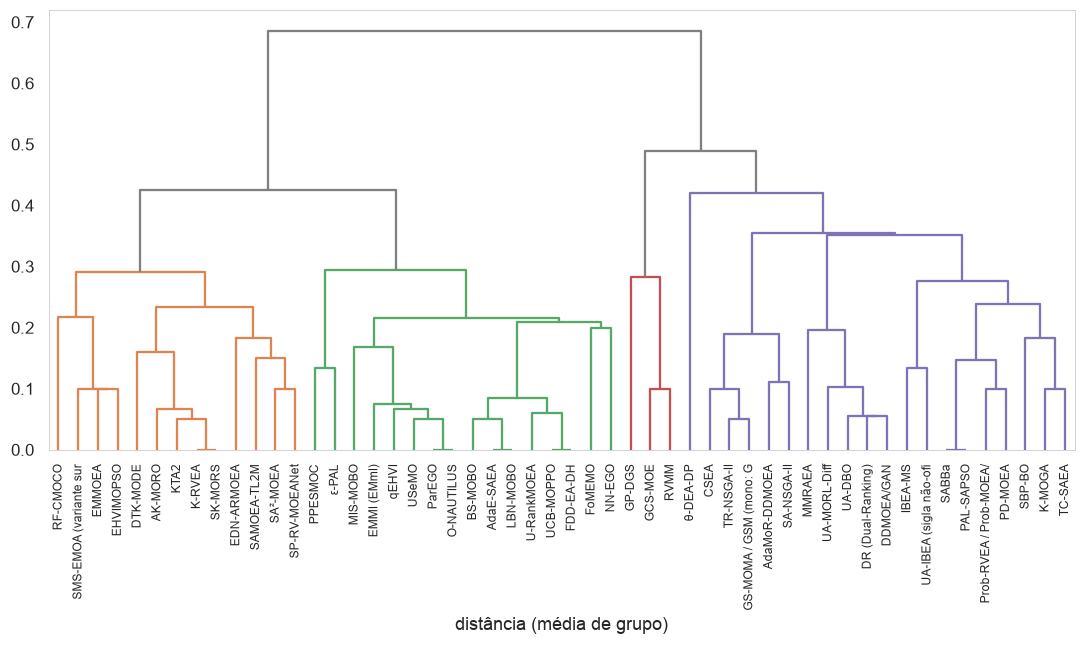

In [23]:
### Dendrograma sobre perfis únicos (um estudo por combinação dos cinco caracteres)
unicos = dfi.loc[nomeados].drop_duplicates(subset=EIXOS).index.tolist()
vu = squareform(df_distancias.loc[unicos, unicos].values, checks=False)
Zu = linkage(vu, method='average')
cofenetica_u, _ = cophenet(Zu, vu)
print(len(unicos), 'perfis únicos · correlação cofenética:', round(cofenetica_u, 3))    # 52 · 0.814

fig, ax = plt.subplots(figsize=(10, 6))
dendrogram(Zu, labels=dfi.loc[unicos, 'acronimo'].str[:22].tolist(), orientation='top', leaf_font_size=8, ax=ax,
           color_threshold=(Zu[-k, 2] + Zu[-k + 1, 2]) / 2, above_threshold_color='grey')
ax.set_xlabel('distância (média de grupo)'); plt.tight_layout(); plt.show()

## [F3] - Agrupamento por partição

In [24]:
### k-medoides (PAM): BUILD (escolha gulosa, determinística) e SWAP (troca enquanto a soma das distâncias cair)
def pam(D, k, candidatos=None):
    """`candidatos` = índices de D que podem ser medoide (None = todos)."""
    n = D.shape[0]
    cand = list(range(n)) if candidatos is None else list(candidatos)
    custo = lambda M: D[:, M].min(axis=1).sum()
    med = [min(cand, key=lambda c: D[:, c].sum())]                # 1º medoide: o candidato mais central
    while len(med) < k:                                            # BUILD: entra quem mais reduz o custo
        dmin = D[:, med].min(axis=1)
        ganho = [(np.maximum(dmin - D[:, c], 0).sum(), -c) for c in cand if c not in med]
        med.append(-max(ganho)[1])
    atual = custo(med)
    while True:                                                    # SWAP: a melhor troca medoide ↔ não-medoide
        melhor = None
        for i, m in enumerate(med):
            for c in cand:
                if c in med: continue
                novo = med[:i] + [c] + med[i + 1:]
                cn = custo(novo)
                if cn < atual - 1e-12 and (melhor is None or cn < melhor[0]):
                    melhor = (cn, novo)
        if melhor is None: break
        atual, med = melhor
    rot = np.argmin(D[:, med], axis=1)
    return rot, med, atual


def ari(r1, r2):
    """Índice de Rand ajustado (Hubert e Arabie, 1985): 1 = mesmas partições, ≈0 = concordância ao acaso."""
    t = pd.crosstab(r1, r2).values
    s_ij = sum(comb(int(x), 2) for x in t.ravel())
    s_a = sum(comb(int(x), 2) for x in t.sum(axis=1)); s_b = sum(comb(int(x), 2) for x in t.sum(axis=0))
    esp = s_a * s_b / comb(int(t.sum()), 2); maxi = (s_a + s_b) / 2
    return 1.0 if maxi == esp else (s_ij - esp) / (maxi - esp)

In [25]:
### Calcula k-medoides (PAM) para k = 1 … 10: uma coluna por k, os medoides e as curvas
completos = [p for p, i in enumerate(nomeados) if dfi.loc[i, EIXOS].notna().all()]     # 112 candidatos a medoide (D3)
df_familias_pam = pd.DataFrame({'id': nomeados})
medoides = {}
linhas = []
for k in range(1, 11):
    rot, med, custo = pam(D, k, completos)
    rot = rotulos_por_tamanho(rot)
    df_familias_pam[f'pam_k{k}'] = rot
    medoides[k] = {int(rot[m]): dfi.at[nomeados[m], 'acronimo'] for m in med}      # família → seu medoide
    tamanhos = df_familias_pam[f'pam_k{k}'].value_counts().tolist()
    linhas.append({'k': k, 'custo': custo,
                   'dist_intra': dist_intra(D, rot),
                   'silhueta': silhueta(D, rot).mean() if k > 1 else np.nan,
                   'ari_vs_hier': ari(rot, df_familias_hier[f'fam_k{k}'].values) if k > 1 else np.nan,
                   'menor_familia': min(tamanhos), 'tamanhos': tamanhos})

# Resumo de metricas por k
dp_curvas_pam = pd.DataFrame(linhas).set_index('k')
dp_curvas_pam

,custo,dist_intra,silhueta,ari_vs_hier,menor_familia,tamanhos
k,,,,,,
1,36.432275,0.416963,NaN,NaN,121,[121]
2,22.120106,0.235129,0.568354,0.573460,38,"[83, 38]"
3,17.829630,0.179347,0.558690,0.552634,20,"[74, 27, 20]"
4,15.496296,0.187937,0.310364,0.600573,20,"[50, 26, 25, 20]"
5,13.628571,0.143994,0.403808,0.585896,8,"[51, 24, 20, 18, 8]"
6,12.428571,0.149936,0.339061,0.333597,8,"[29, 25, 24, 18, 17, 8]"
7,11.228571,0.141693,0.398247,0.301822,8,"[25, 24, 18, 17, 15, 14, 8]"
8,10.238095,0.131741,0.428980,0.287386,8,"[25, 24, 18, 16, 11, 11, 8, 8]"
9,9.271429,0.112117,0.479929,0.305371,4,"[25, 21, 18, 16, 11, 10, 8, 8, 4]"


In [26]:
### Junta ao df3: os 6 de resíduo de função ficam com 0 (família de resíduos)
df4 = df3.merge(df_familias_pam, on='id', how='left')
cols_pam = [c for c in df4.columns if c.startswith('pam_k')]
df4[cols_pam] = df4[cols_pam].fillna(0).astype(int)

print(df4.shape)
df4.head()

(127, 35)


,id,acronimo,funcao,motor,regime,surrogate,medicao,atitude_funcao,objeto_funcao,paradigma_motor,...,pam_k1,pam_k2,pam_k3,pam_k4,pam_k5,pam_k6,pam_k7,pam_k8,pam_k9,pam_k10
0,b1,ParEGO,OV,BO-Decomposição,online,GP,VA,oportunidade,valor,BO,...,1,1,1,1,1,1,6,5,6,6
1,b13,AdaMoR-DDMOEA,AM,EA-Decomposição,offline,NN,EE,ameaça,modelo,EA,...,1,2,2,2,5,6,7,7,7,7
2,b14,SA²-MOEA,OM,EA-Dominância,online,RG,DE,oportunidade,modelo,EA,...,1,2,3,4,3,5,4,8,8,8
3,b15,U-RankMOEA,OV,BO-Especiais,online,GP,DE,oportunidade,valor,BO,...,1,1,1,1,2,3,2,2,2,4
4,b2,MOEA/D-EGO,OV,BO-Decomposição,online,GP,VA,oportunidade,valor,BO,...,1,1,1,1,1,1,6,5,6,6


In [27]:
resumo_particao(df4, 'pam_k3')

,n,tipo,atitude,paradigma,fonte,regime,membros
familia,,,,,,,
1,74,qEHVI,"{'oportunidade': 71, 'ameaça': 3}","{'BO': 70, nan: 3, 'EA': 1}","{'analítica': 64, 'fabricada': 10}",{'online': 74},"ParEGO, U-RankMOEA, MOEA/D-EGO, USeMO, BS-MOBO, qEHVI, SMS-EGO, EMMI (EMmI), MS-VHGP-EIHV, AdaE-SAEA, EPBII / EIPBII, MORBO, PPESMOC, LBN-MOBO, JES, FoMEMO,..."
2,27,K-MOGA,{'ameaça': 27},"{'EA': 24, nan: 2, 'BO': 1}","{'fabricada': 14, 'analítica': 13}","{'online': 15, 'offline': 12}","AdaMoR-DDMOEA, CSEA, Prob-RVEA / Pr, DR (Dual-Ranki, θ-DEA-DP, DDMOEA/GAN, MMRAEA, PC-SAEA, K-MOGA, GP-DGS, IBE-CSEA, PD-MOEA, UA-DBO, SABBa, PAL-SAPSO, UA-..."
3,20,AK-MORO,{'oportunidade': 20},"{'EA': 19, nan: 1}","{'analítica': 13, 'fabricada': 7}","{'online': 19, 'offline': 1}","SA²-MOEA, K-RVEA, KTA2, SP-RV-MOEANet, DTK-MODE, EMMOEA, SAMOEA-TL2M, EHVIMOPSO, AK-MORO, KAEA-C, SK-MORS, EDN-ARMOEA, CLMEA, HET-EMO (HET-N, NSGAIII-EHVI, ..."


In [28]:
resumo_particao(df4, 'pam_k4')

,n,tipo,atitude,paradigma,fonte,regime,membros
familia,,,,,,,
1,50,USeMO,"{'oportunidade': 46, 'ameaça': 4}","{'BO': 47, nan: 3}","{'analítica': 42, 'fabricada': 8}","{'online': 49, 'offline': 1}","ParEGO, U-RankMOEA, MOEA/D-EGO, USeMO, EMMI (EMmI), AdaE-SAEA, EPBII / EIPBII, PPESMOC, LBN-MOBO, JES, FoMEMO, PDBO, UCB-MOPPO, PFES, MESMO, GCS-MOE, Multi-..."
2,26,K-MOGA,{'ameaça': 26},"{'EA': 24, nan: 2}","{'fabricada': 14, 'analítica': 12}","{'online': 15, 'offline': 11}","AdaMoR-DDMOEA, CSEA, Prob-RVEA / Pr, DR (Dual-Ranki, θ-DEA-DP, DDMOEA/GAN, MMRAEA, PC-SAEA, K-MOGA, IBE-CSEA, PD-MOEA, UA-DBO, SABBa, PAL-SAPSO, UA-MORL-Dif..."
3,25,qEHVI,{'oportunidade': 25},"{'BO': 24, 'EA': 1}","{'analítica': 23, 'fabricada': 2}",{'online': 25},"BS-MOBO, qEHVI, SMS-EGO, MS-VHGP-EIHV, MORBO, HDGP-BO, MO-DGP, VFMOEGO (crité, qNEHVI (NEHVI , EMO, EGBO, MOBO, FanG-HPO, Trust-MOMF (e , CHVEI / CHVPOI, TS..."
4,20,AK-MORO,{'oportunidade': 20},"{'EA': 19, nan: 1}","{'analítica': 13, 'fabricada': 7}","{'online': 19, 'offline': 1}","SA²-MOEA, K-RVEA, KTA2, SP-RV-MOEANet, DTK-MODE, EMMOEA, SAMOEA-TL2M, EHVIMOPSO, AK-MORO, KAEA-C, SK-MORS, EDN-ARMOEA, CLMEA, HET-EMO (HET-N, NSGAIII-EHVI, ..."


In [29]:
medoides[4]

{1: 'USeMO', 2: 'K-MOGA', 4: 'AK-MORO', 3: 'qEHVI'}

# [DP] - Depara oficial com relacao de familias por algoritmos

In [30]:
### [F5] Auditoria (D-E): entre os nove com carácter ausente fora da função, silhueta negativa em k = 4 → resíduos
rot = df4.loc[df4['fam_k4'] > 0, 'fam_k4'].values                 # os 121, na ordem de nomeados
s = silhueta(D, rot)
nove = dfi.loc[nomeados, EIXOS].isna().any(axis=1).values
auditados = np.array(nomeados)[nove & (s < 0)]
dfi.loc[auditados, 'acronimo'].tolist()                            # esperado: ['SABBa', 'UA-MORL-Diff']

['SABBa', 'UA-MORL-Diff']

In [31]:
### As colunas oficiais: família (k = 4 auditado) e subfamília (k = 7 só na ameaça evolutiva; θ-DEA-DP é caso isolado — D-D), nomes e cores
df4['familia'] = df4['fam_k4'].where(~df4['id'].isin(auditados), 0)
df4['subfamilia'] = df4['fam_k7'].where(df4['familia'] == 2, 0).replace({3: 1, 4: 2, 5: 3, 7: 0})
NOME_FAM = {1: 'oportunidade bayesiana', 2: 'ameaça evolutiva', 3: 'oportunidade evolutiva', 4: 'ameaça bayesiana', 0: 'resíduos'}
NOME_SUB = {1: 'analítica', 2: 'por erro empírico', 3: 'por discordância'}
COR_FAM  = {1: '#1f77b4', 2: '#d62728', 3: '#2ca02c', 4: '#9467bd', 0: '#7f7f7f'}
COR_SUB  = {1: '#d62728', 2: '#ff7f0e', 3: '#8c564b'}
print(df4['familia'].value_counts().sort_index().to_dict(), df4['subfamilia'].value_counts().sort_index().to_dict())
resumo_particao(df4, 'familia')

{0: 8, 1: 70, 2: 24, 3: 21, 4: 4} {0: 104, 1: 11, 2: 7, 3: 5}


,n,tipo,atitude,paradigma,fonte,regime,membros
familia,,,,,,,
1,70,qEHVI,{'oportunidade': 70},"{'BO': 67, nan: 3}","{'analítica': 60, 'fabricada': 10}",{'online': 70},"ParEGO, U-RankMOEA, MOEA/D-EGO, USeMO, BS-MOBO, qEHVI, SMS-EGO, EMMI (EMmI), MS-VHGP-EIHV, AdaE-SAEA, EPBII / EIPBII, MORBO, PPESMOC, LBN-MOBO, JES, FoMEMO,..."
2,24,K-MOGA,{'ameaça': 24},{'EA': 24},"{'fabricada': 13, 'analítica': 11}","{'online': 14, 'offline': 10}","AdaMoR-DDMOEA, CSEA, Prob-RVEA / Pr, DR (Dual-Ranki, θ-DEA-DP, DDMOEA/GAN, MMRAEA, PC-SAEA, K-MOGA, IBE-CSEA, PD-MOEA, UA-DBO, PAL-SAPSO, TC-SAEA, IBEA-MS, ..."
3,21,AK-MORO,{'oportunidade': 21},"{'EA': 20, nan: 1}","{'analítica': 14, 'fabricada': 7}","{'online': 20, 'offline': 1}","SA²-MOEA, K-RVEA, KTA2, SP-RV-MOEANet, DTK-MODE, EMMOEA, SAMOEA-TL2M, EHVIMOPSO, AK-MORO, KAEA-C, SK-MORS, EDN-ARMOEA, CLMEA, HET-EMO (HET-N, NSGAIII-EHVI, ..."
4,4,RVMM,{'ameaça': 4},{'BO': 4},{'analítica': 4},"{'online': 3, 'offline': 1}","GCS-MOE, GP-DGS, RVMM, ATKIS"


In [32]:
# Exporta o de-para oficial dos 127 estudos: 5 eixos + família (k = 4 auditada) + subfamília (k = 7) — insumo do notebook 2
dp = df4[['id', 'acronimo'] + EIXOS + ['familia', 'subfamilia']].copy()
dp['familia_nome']    = dp['familia'].map(NOME_FAM)
dp['subfamilia_nome'] = dp['subfamilia'].map(NOME_SUB)
dp['caso_isolado']    = df4['fam_k7'] == 7                 # θ-DEA-DP (D-D)
dp.to_parquet(MESTRADO / 'ua-dd-saea/analises_finais/df_familias.parquet')

In [33]:
dp['familia'].value_counts()

familia
1    70
2    24
3    21
0     8
4     4
Name: count, dtype: int64

In [34]:
dp

,id,acronimo,funcao,motor,regime,surrogate,medicao,familia,subfamilia,familia_nome,subfamilia_nome,caso_isolado
0,b1,ParEGO,OV,BO-Decomposição,online,GP,VA,1,0,oportunidade bayesiana,NaN,False
1,b13,AdaMoR-DDMOEA,AM,EA-Decomposição,offline,NN,EE,2,2,ameaça evolutiva,por erro empírico,False
2,b14,SA²-MOEA,OM,EA-Dominância,online,RG,DE,3,0,oportunidade evolutiva,NaN,False
3,b15,U-RankMOEA,OV,BO-Especiais,online,GP,DE,1,0,oportunidade bayesiana,NaN,False
4,b2,MOEA/D-EGO,OV,BO-Decomposição,online,GP,VA,1,0,oportunidade bayesiana,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...
122,o56,ε-PoHVI,OV,BO-Hipervolume,online,GP,VA,1,0,oportunidade bayesiana,NaN,False
123,o6,KEMOCO,OV,BO-Hipervolume,online,GP,VA,1,0,oportunidade bayesiana,NaN,False
124,pp6,AB-MOEA,AV,EA-Decomposição,online,GP,VA,2,1,ameaça evolutiva,analítica,False
125,wang4,SA-NSGA-II,AM,EA-Dominância,offline,None,EE,2,2,ameaça evolutiva,por erro empírico,False


## [F] Figuras dissertação

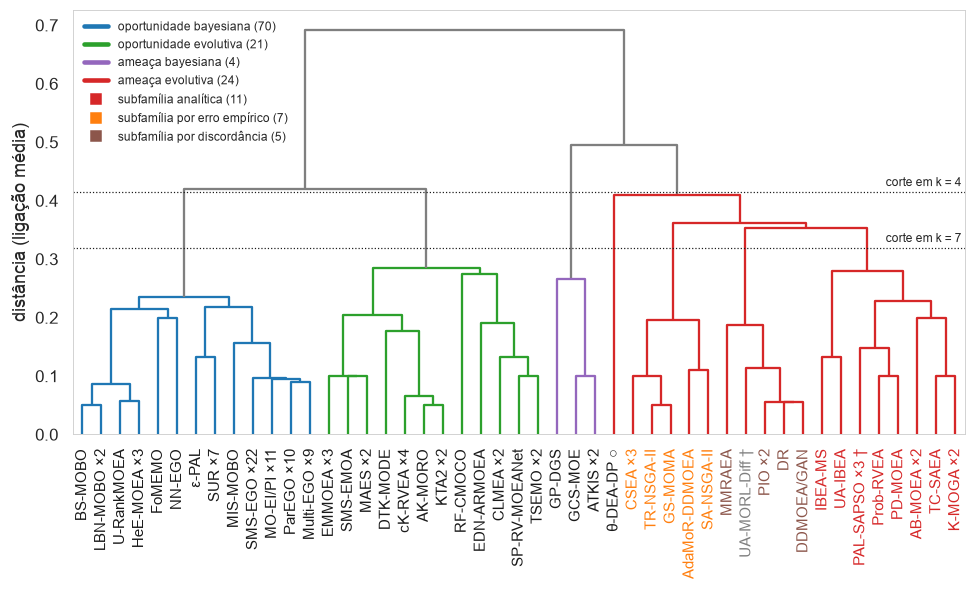

In [35]:
### F1 · Dendrograma das famílias: a árvore dos 121 com as junções de altura zero contraídas (uma folha por bloco a distância zero)
import re
def contrair_zeros(Z):
    n = Z.shape[0] + 1
    bloco = {i: i for i in range(n)}                                   # nó da árvore → bloco
    for m in np.where(np.isclose(Z[:, 2], 0))[0]:                      # as junções de altura 0 fundem blocos
        a, b = bloco[int(Z[m, 0])], bloco[int(Z[m, 1])]
        bloco[n + m] = a
        bloco.update({x: a for x in bloco if bloco[x] == b})
    folha = {b: j for j, b in enumerate(sorted(set(bloco[i] for i in range(n))))}    # bloco → folha
    membros = {j: [i for i in range(n) if folha[bloco[i]] == j] for j in folha.values()}
    Zc, tam = [], {j: 1 for j in folha.values()}
    for m in np.where(~np.isclose(Z[:, 2], 0))[0]:                     # as demais junções são copiadas como estão
        a, b = folha[bloco[int(Z[m, 0])]], folha[bloco[int(Z[m, 1])]]
        j = len(membros) + len(Zc); tam[j] = tam[a] + tam[b]
        Zc.append([a, b, Z[m, 2], tam[j]]); folha[n + m] = j; bloco[n + m] = n + m
    return np.array(Zc), membros

Zc, membros = contrair_zeros(Z)
dfi['ano']  = pd.Series({i: base[i]['ano'] for i in ids})
dfi['nome'] = pd.Series({i: re.split(r' \(| / ', base[i]['acronimo'])[0] for i in ids})   # nome de exibição: sem parênteses e variantes
ofi = df4.set_index('id').join(dfi[['ano', 'nome']])
folhas = []
for j, ps in membros.items():                                          # cada folha: o estudo mais antigo do bloco, o n e as marcas
    g = ofi.loc[[nomeados[p] for p in ps]].sort_values(['ano', 'nome'])
    folhas.append({'rotulo': g['nome'].iloc[0] + (f' ×{len(g)}' if len(g) > 1 else '') + (' †' if (g['familia'] == 0).any() else '') + (' ○' if (g['fam_k7'] == 7).any() else ''),
                   'fam': g['fam_k4'].iloc[0], 'sub': g['subfamilia'].max(), 'residuo': (g['familia'] == 0).all()})
folhas = pd.DataFrame(folhas)
corte  = (Z[-4, 2] + Z[-3, 2]) / 2                                     # a altura do corte em k = 4
corte7 = (Z[-7, 2] + Z[-6, 2]) / 2                                     # a altura do corte em k = 7 (as subfamílias)
cor_no = {j: COR_FAM[f] for j, f in folhas['fam'].items()}             # cor de cada nó: a da família abaixo do corte, cinza acima
for r, (a, b, h, _) in enumerate(Zc):
    cor_no[len(folhas) + r] = cor_no[int(a)] if h < corte else '#7f7f7f'

fig, ax = plt.subplots(figsize=(9, 5.5))
dend = dendrogram(Zc, labels=folhas['rotulo'].tolist(), leaf_font_size=10, ax=ax, link_color_func=lambda k: cor_no[k])
ax.axhline(corte, color='k', ls=':', lw=0.8); ax.text(ax.get_xlim()[1], corte + 0.01, 'corte em k = 4 ', ha='right', fontsize=8)
ax.axhline(corte7, color='k', ls=':', lw=0.8); ax.text(ax.get_xlim()[1], corte7 + 0.01, 'corte em k = 7 ', ha='right', fontsize=8)
for lab, j in zip(ax.get_xticklabels(), dend['leaves']):              # rótulo colorido pela subfamília (cinza = resíduo)
    lab.set_color(COR_SUB.get(folhas.at[j, 'sub'], '#7f7f7f' if folhas.at[j, 'residuo'] else 'k'))
ax.set_ylabel('distância (ligação média)')
ax.legend(handles=[plt.Line2D([], [], color=COR_FAM[f], lw=3, label=f'{NOME_FAM[f]} ({(df4["familia"] == f).sum()})') for f in (1, 3, 4, 2)]
                + [plt.Line2D([], [], color=COR_SUB[s_], lw=0, marker='s', label=f'subfamília {NOME_SUB[s_]} ({(df4["subfamilia"] == s_).sum()})') for s_ in (1, 2, 3)],
          loc='upper left', fontsize=8, frameon=False)
plt.tight_layout(); plt.savefig(MESTRADO / 'dissertacao/figures/fig371_dendrograma.pdf', bbox_inches='tight'); plt.show()

explica: [50.7 15.9] | massa negativa 6.4 de 21.32 | correlação distâncias × plano: 0.953


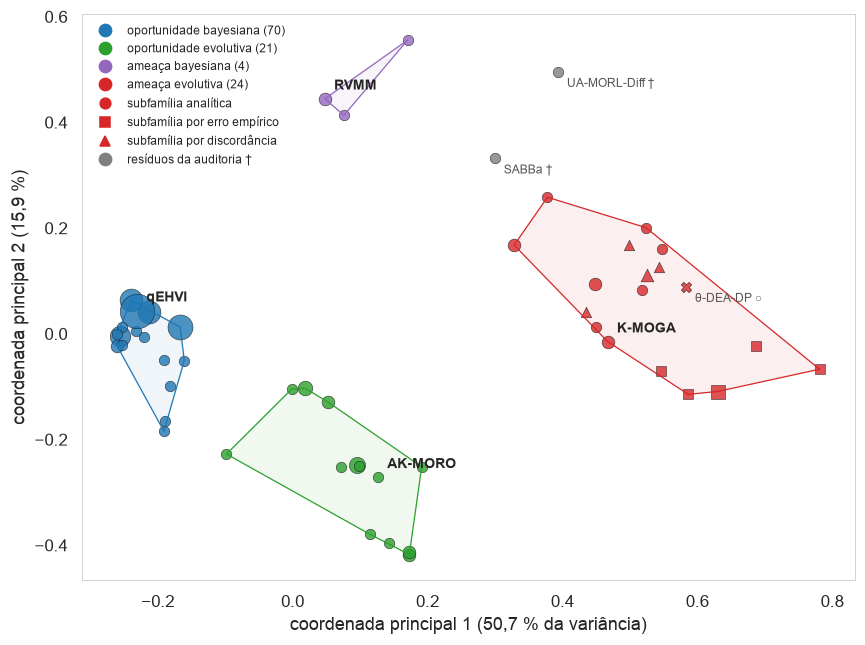

In [36]:
### F2 · O mapa das famílias: coordenadas principais (PCoA, Gower 1966) sobre a matriz de distâncias dos 121
from scipy.spatial import ConvexHull
from scipy.spatial.distance import pdist
n = len(nomeados); J = np.eye(n) - 1 / n
B = -0.5 * J @ (D ** 2) @ J                                            # produtos internos centrados (Gower, 1966)
w, V = np.linalg.eigh(B); w, V = w[::-1], V[:, ::-1]                   # autovalores em ordem decrescente
X = V[:, :2] * np.sqrt(w[:2])                                          # as duas primeiras coordenadas
explica = 100 * w[:2] / w[w > 0].sum()                                 # % da variância positiva (há autovalores negativos: a distância não é euclidiana)
print('explica:', np.round(explica, 1), '| massa negativa', round(-w[w < 0].sum(), 2), 'de', round(w[w > 0].sum(), 2),
      '| correlação distâncias × plano:', round(np.corrcoef(squareform(D, checks=False), pdist(X))[0, 1], 3))

pontos = ofi.loc[nomeados].assign(x=X[:, 0], y=X[:, 1])
pontos['perfil'] = dfi.loc[nomeados, EIXOS].fillna('—').astype(str).agg(' '.join, axis=1).values
perfis = pontos.groupby('perfil').agg(x=('x', 'first'), y=('y', 'first'), n=('x', 'size'), familia=('familia', 'first'), subfamilia=('subfamilia', 'first'))
MARC = {1: 'o', 2: 's', 3: '^', 0: 'X'}                                 # subfamílias da ameaça evolutiva; X = caso isolado

fig, ax = plt.subplots(figsize=(8, 6))
for f in (1, 2, 3, 4):                                                 # o contorno convexo de cada família
    P = pontos.loc[pontos['familia'] == f, ['x', 'y']].values; v = np.r_[ConvexHull(P).vertices, ConvexHull(P).vertices[0]]
    ax.fill(P[v, 0], P[v, 1], color=COR_FAM[f], alpha=0.07); ax.plot(P[v, 0], P[v, 1], color=COR_FAM[f], lw=0.8)
for _, p in perfis.iterrows():                                         # um ponto por perfil único, tamanho ∝ n
    ax.scatter(p['x'], p['y'], s=25 + 22 * p['n'], c=COR_FAM[p['familia']], marker=MARC[p['subfamilia']] if p['familia'] == 2 else 'o', alpha=0.8, edgecolor='k', lw=0.4)
for f in (1, 2, 3, 4):                                                 # o tipo de cada família
    t = tipo_da_familia(df4.loc[df4['familia'] == f, 'id'].tolist())
    ax.annotate(ofi.at[t, 'nome'], (pontos.at[t, 'x'], pontos.at[t, 'y']), xytext=(6, 6), textcoords='offset points', fontsize=9, fontweight='bold')
for i, marca in [(auditados[0], ' †'), (auditados[1], ' †'), (pontos.index[pontos['fam_k7'] == 7][0], ' ○')]:
    ax.annotate(ofi.at[i, 'nome'] + marca, (pontos.at[i, 'x'], pontos.at[i, 'y']), xytext=(6, -10), textcoords='offset points', fontsize=8, color='#555555')
ax.set_xlabel(f'coordenada principal 1 ({explica[0]:.1f} % da variância)'.replace('.', ',')); ax.set_ylabel(f'coordenada principal 2 ({explica[1]:.1f} %)'.replace('.', ','))
ax.legend(handles=[plt.Line2D([], [], color=COR_FAM[f], lw=0, marker='o', ms=8, label=f'{NOME_FAM[f]} ({(df4["familia"] == f).sum()})') for f in (1, 3, 4, 2)]
                + [plt.Line2D([], [], color=COR_FAM[2], lw=0, marker=MARC[s_], ms=7, label=f'subfamília {NOME_SUB[s_]}') for s_ in (1, 2, 3)]
                + [plt.Line2D([], [], color=COR_FAM[0], lw=0, marker='o', ms=8, label='resíduos da auditoria †')],
          loc='upper left', fontsize=8, frameon=False)
plt.tight_layout(); plt.savefig(MESTRADO / 'dissertacao/figures/fig372_mapa.pdf', bbox_inches='tight'); plt.show()

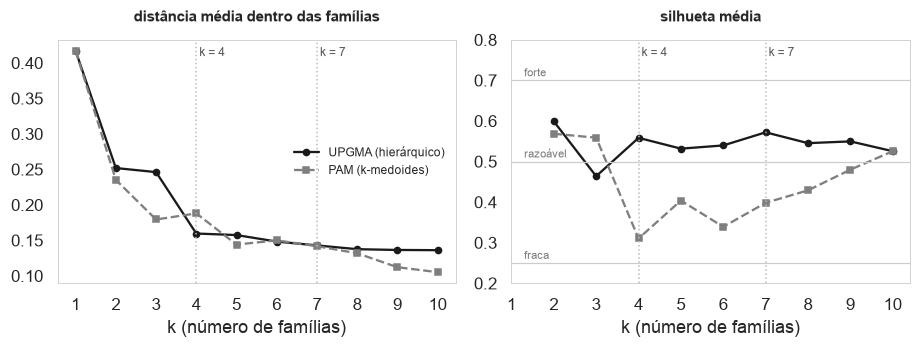

In [37]:
### F3 · As curvas por k: distância média dentro das famílias e silhueta média, UPGMA (oficial) e PAM (validação)
fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.3))
axes[1].set_ylim(0.2, 0.8)
for ax, col, titulo in zip(axes, ['dist_intra', 'silhueta'], ['distância média dentro das famílias', 'silhueta média']):
    ax.plot(dp_curvas_hier.index, dp_curvas_hier[col], 'o-', color='k', ms=4, label='UPGMA (hierárquico)')
    ax.plot(dp_curvas_pam.index, dp_curvas_pam[col], 's--', color='#7f7f7f', ms=4, label='PAM (k-medoides)')
    for k in (4, 7): ax.axvline(k, color='#bbbbbb', ls=':', lw=1); ax.text(k, 0.97, f' k = {k}', transform=ax.get_xaxis_transform(), fontsize=8, va='top', color='#555555')
    ax.set_xticks(range(1, 11)); ax.set_xlabel('k (número de famílias)'); ax.set_title(titulo, fontsize=10)
for y, faixa in [(0.25, 'fraca'), (0.50, 'razoável'), (0.70, 'forte')]:      # a escala de Kaufman e Rousseeuw (1990)
    axes[1].axhline(y, color='#cccccc', lw=0.8); axes[1].text(1.3, y + 0.01, faixa, fontsize=7, color='#777777')
axes[0].legend(fontsize=8, frameon=False, loc='center right')
plt.tight_layout(); plt.savefig(MESTRADO / 'dissertacao/figures/fig373_curvas.pdf', bbox_inches='tight'); plt.show()

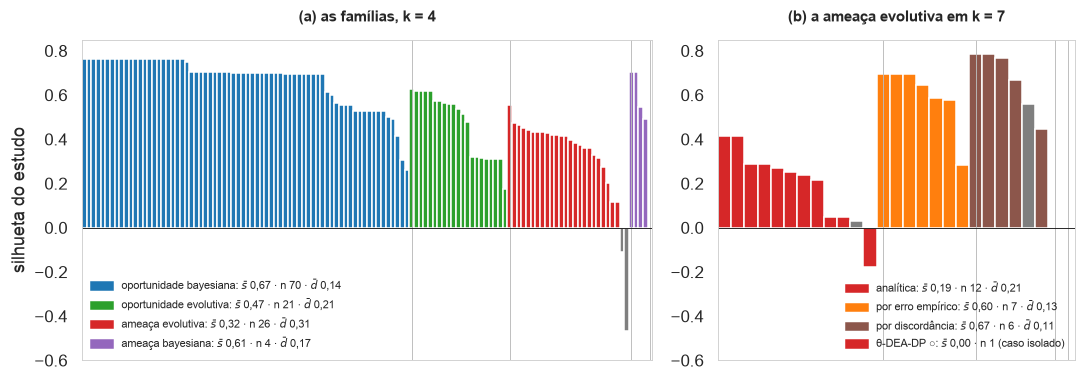

In [38]:
### F4 · As silhuetas por estudo: (a) as quatro famílias em k = 4; (b) o segundo nível, as subfamílias da ameaça evolutiva em k = 7
def painel_silhueta(ax, col, grupos, nomes, cores, loc='lower left'):
    q = df4[df4[col] > 0].copy(); q['s'] = silhueta(D, q[col].values)          # os 121, na ordem de nomeados
    fmt = lambda v: f'{v:.2f}'.replace('.', ',')
    x, legenda = 0, []
    for g in grupos:
        m = q[q[col] == g].sort_values('s', ascending=False); k_ = len(m)
        ax.bar(np.arange(x, x + k_), m['s'], width=1.0, color=[cores[g] if f else '#7f7f7f' for f in m['familia']])   # cinza = resíduo da auditoria
        d = dist_intra(D[np.ix_(q[col].values == g, q[col].values == g)], np.zeros(k_))
        legenda.append(plt.Rectangle((0, 0), 1, 1, color=cores[g], label=f'{nomes[g]}: $\\bar{{s}}$ {fmt(m["s"].mean())} · n {k_}' + (f' · $\\bar{{d}}$ {fmt(d)}' if k_ > 1 else ' (caso isolado)')))
        ax.axvline(x + k_, color='#bbbbbb', lw=0.6); x += k_
    ax.axhline(0, color='k', lw=0.6); ax.set_xlim(-0.5, x + 0.5); ax.set_ylim(-0.6, 0.85); ax.set_xticks([])
    ax.legend(handles=legenda, loc=loc, fontsize=7, frameon=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), gridspec_kw={'width_ratios': [2, 1.25]})
painel_silhueta(axes[0], 'fam_k4', [1, 3, 2, 4], NOME_FAM, COR_FAM)
painel_silhueta(axes[1], 'fam_k7', [3, 4, 5, 7], {3: 'analítica', 4: 'por erro empírico', 5: 'por discordância', 7: 'θ-DEA-DP ○'}, {3: COR_SUB[1], 4: COR_SUB[2], 5: COR_SUB[3], 7: COR_FAM[2]}, loc='lower right')
axes[0].set_ylabel('silhueta do estudo'); axes[0].set_title('(a) as famílias, k = 4', fontsize=10); axes[1].set_title('(b) a ameaça evolutiva em k = 7', fontsize=10)
plt.tight_layout(); plt.savefig(MESTRADO / 'dissertacao/figures/fig374_silhuetas.pdf', bbox_inches='tight'); plt.show()

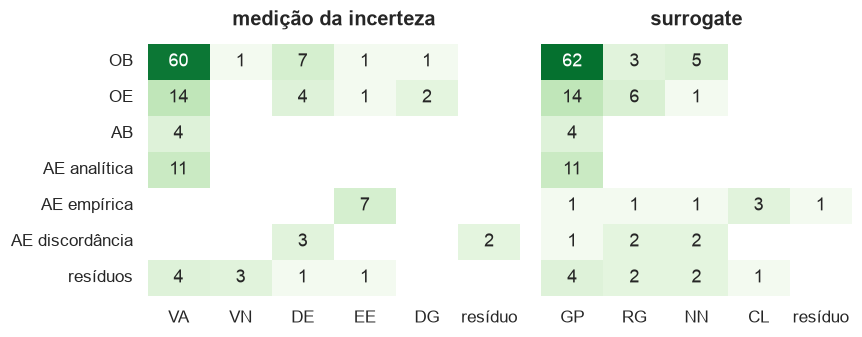

In [39]:
### F5 · O perfil das famílias por surrogate e por medição: linhas = as seis famílias (siglas) e os resíduos (com o caso isolado); n por célula
ORDEM = {'medicao': ['VA', 'VN', 'DE', 'EE', 'DG', 'resíduo'], 'surrogate': ['GP', 'RG', 'NN', 'CL', 'resíduo']}
TITULO = {'surrogate': 'surrogate', 'medicao': 'medição da incerteza'}
SIGLA = {1: 'OB', 3: 'OE', 4: 'AB', 2: 'AE', 0: 'resíduos'}; SIGLA_SUB = {1: 'AE analítica', 2: 'AE empírica', 3: 'AE discordância'}
q = df4.copy(); q[EIXOS] = q[EIXOS].fillna('resíduo')
q['grupo'] = np.where(q['familia'] == 2, q['subfamilia'].map(SIGLA_SUB), q['familia'].map(SIGLA))
q.loc[(q['familia'] == 0) | (q['fam_k7'] == 7), 'grupo'] = 'resíduos'
LINHAS = ['OB', 'OE', 'AB'] + list(SIGLA_SUB.values()) + ['resíduos']

fig, axes = plt.subplots(1, 2, figsize=(8, 3.2), gridspec_kw={'width_ratios': [len(v) for v in ORDEM.values()]})
for ax, (eixo, ordem) in zip(axes, ORDEM.items()):
    heatmap_2d(q, 'grupo', eixo, vmax=70, ax=ax, ordem_linhas=LINHAS, ordem_colunas=ordem, titulo=TITULO[eixo], escala_fonte=1.0, rot_x=0)
    for t in ax.texts: t.set_fontsize(t.get_fontsize() * 0.8)          # os números das células 20 % menores
    if ax is not axes[0]: ax.set_yticklabels([])
plt.tight_layout(); plt.savefig(MESTRADO / 'dissertacao/figures/fig375_perfil.pdf', bbox_inches='tight'); plt.show()

## Análise - Sensibilidade aos pesos

In [40]:
### Os 14 cenários de pesos: referência, iguais, cada eixo zerado, cada eixo dominante (0,5) e dois pares dominantes
REF = np.array([PESOS[e] for e in EIXOS])
CENARIOS = {'referencia': REF, 'iguais': np.full(5, 0.2)}
for j, e in enumerate(EIXOS):
    w = REF.copy(); w[j] = 0; CENARIOS[f'sem {e}'] = w / w.sum()
    w = REF.copy(); w[j] = 0; w = 0.5 * w / w.sum(); w[j] = 0.5; CENARIOS[f'{e} dominante'] = w
for nome, par in [('fonte dominante', [3, 4]), ('maquinaria dominante', [1, 3])]:
    w = REF.copy(); w[par] = 0; w = 0.5 * w / w.sum(); w[par] = 0.25; CENARIOS[nome] = w

pd.DataFrame(CENARIOS, index=EIXOS).T.round(3)

,funcao,motor,regime,surrogate,medicao
referencia,0.400,0.300,0.100,0.100,0.100
iguais,0.200,0.200,0.200,0.200,0.200
sem funcao,0.000,0.500,0.167,0.167,0.167
funcao dominante,0.500,0.250,0.083,0.083,0.083
sem motor,0.571,0.000,0.143,0.143,0.143
motor dominante,0.286,0.500,0.071,0.071,0.071
sem regime,0.444,0.333,0.000,0.111,0.111
regime dominante,0.222,0.167,0.500,0.056,0.056
sem surrogate,0.444,0.333,0.111,0.000,0.111
surrogate dominante,0.222,0.167,0.056,0.500,0.056


In [41]:
### Para cada cenário: matriz sobre os 121, árvore UPGMA, cortes em k = 4 e 7, e o Jaccard de cada família oficial com a mais parecida do cenário
def matriz(pesos):
    M = np.zeros((len(nomeados), len(nomeados)))
    for p, i in enumerate(nomeados):
        for q in range(p + 1, len(nomeados)):
            M[p, q] = M[q, p] = gower(i, nomeados[q], pesos)
    return M

def jaccard_familias(ref, alt):
    """Para cada família de referência, o Jaccard com a família do cenário que mais se parece com ela (Hennig, 2007)."""
    conj = lambda rot, g: set(np.where(rot == g)[0])
    return {g: max(len(conj(ref, g) & conj(alt, h)) / len(conj(ref, g) | conj(alt, h)) for h in np.unique(alt)) for g in np.unique(ref)}

linhas = []; particoes = {}
for nome, w in CENARIOS.items():
    Zc = linkage(squareform(matriz(dict(zip(EIXOS, w))), checks=False), 'average')
    for k in (4, 7):
        particoes[(nome, k)] = cortar(Zc, k)[0]
        for fam, j in jaccard_familias(df_familias_hier[f'fam_k{k}'].values, particoes[(nome, k)]).items():
            linhas.append({'cenario': nome, 'k': k, 'familia': fam, 'jaccard': j})
dp_sensibilidade = pd.DataFrame(linhas)

# Jaccard por família oficial (1 = a maior) em cada cenário; estável a partir de 0,75
dp_sensibilidade[dp_sensibilidade['k'] == 4].pivot(index='cenario', columns='familia', values='jaccard').loc[list(CENARIOS)].round(2)

familia,1,2,3,4
cenario,,,,
referencia,1.00,1.00,1.00,1.00
iguais,0.65,0.39,0.23,0.06
sem funcao,0.93,0.41,0.56,0.05
funcao dominante,0.91,0.63,0.67,0.23
sem motor,0.77,0.60,0.23,0.18
motor dominante,1.00,1.00,1.00,1.00
sem regime,1.00,1.00,1.00,1.00
regime dominante,0.75,0.58,0.21,0.07
sem surrogate,1.00,1.00,1.00,1.00


In [42]:
dp_sensibilidade[dp_sensibilidade['k'] == 7].pivot(index='cenario', columns='familia', values='jaccard').loc[list(CENARIOS)].round(2)

familia,1,2,3,4,5,6,7
cenario,,,,,,,
referencia,1.00,1.00,1.00,1.00,1.00,1.00,1.00
iguais,0.65,0.32,0.29,0.71,0.62,0.11,1.00
sem funcao,0.81,0.43,0.31,0.33,0.38,0.06,1.00
funcao dominante,0.91,0.67,0.38,0.64,0.67,0.75,1.00
sem motor,0.82,0.29,0.69,1.00,0.71,0.43,1.00
motor dominante,1.00,1.00,0.33,0.46,1.00,1.00,0.17
sem regime,1.00,0.67,0.67,1.00,0.33,1.00,1.00
regime dominante,1.00,0.95,0.42,0.29,0.42,0.75,0.07
sem surrogate,1.00,1.00,0.54,0.70,0.75,0.75,0.12


In [43]:
### O que os pesos iguais fazem com o corpus: as famílias viram o tipo de surrogate
pd.crosstab(particoes[('iguais', 4)], dfi.loc[nomeados, 'surrogate'].fillna('nan').values)

col_0,CL,GP,NN,RG,nan
row_0,,,,,
0,0,85,0,0,0
1,0,7,4,1,1
2,0,1,6,10,0
3,4,1,0,1,0


## Análise de resultados

In [44]:
### Teoria × dados: ARI das partições oficiais com as grades teóricas, nos 115 com paradigma nomeado
t = df4[(df4['fam_k4'] > 0) & df4['paradigma_motor'].notna()]
grade5 = np.where((t['atitude_funcao'] == 'ameaça') & (t['paradigma_motor'] == 'EA'), t['familia_teorica'], t['atitude_funcao'] + '_' + t['paradigma_motor'])
{'k4 × atitude·paradigma': ari(t['fam_k4'], t['atitude_funcao'] + '_' + t['paradigma_motor']),
 'k4 × familia_teorica (7 células)': ari(t['fam_k4'], t['familia_teorica']),
 'k7 × atitude·paradigma + fonte na ameaça evolutiva': ari(t['fam_k7'], grade5),
 'k7 × familia_teorica (7 células)': ari(t['fam_k7'], t['familia_teorica'])}

{'k4 × atitude·paradigma': 1.0,
 'k4 × familia_teorica (7 células)': 0.7678856727735842,
 'k7 × atitude·paradigma + fonte na ameaça evolutiva': 0.9848434646250346,
 'k7 × familia_teorica (7 células)': 0.7943505931639566}

pam_k4,1,2,3,4,0
fam_k3,,,,,
1,46,0,25,20,0
2,0,26,0,0,0
0,0,0,0,0,6
3,4,0,0,0,0


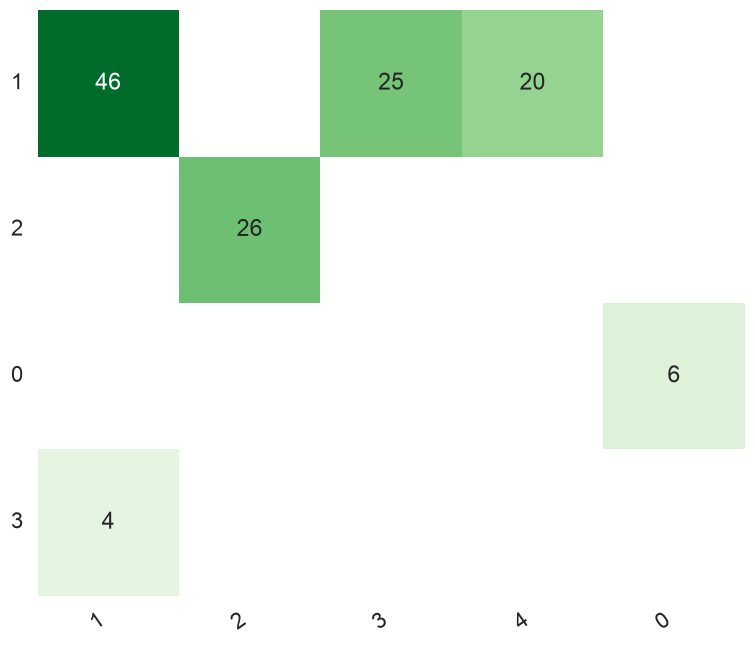

In [45]:
heatmap_2d(df4, 'fam_k3', 'pam_k4')        # onde os dois métodos concordam e discordam

pam_k4,1,2,3,4,0
fam_k4,,,,,
1,46,0,24,0,0
2,0,26,0,0,0
3,0,0,1,20,0
0,0,0,0,0,6
4,4,0,0,0,0


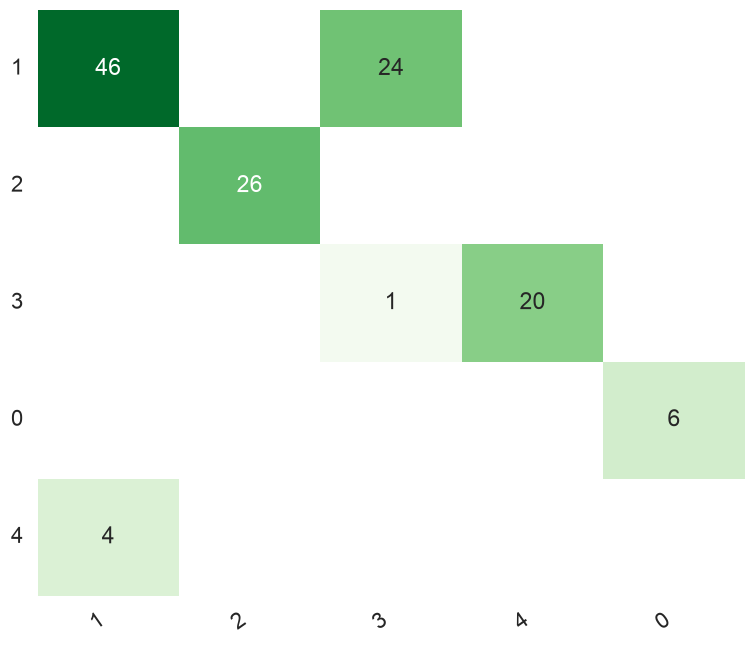

In [46]:
heatmap_2d(df4, 'fam_k4', 'pam_k4')        # onde os dois métodos concordam e discordam

familia_teorica,BO_oportunidade_analítica,EA_ameaça_fabricada,EA_oportunidade_analítica,EA_ameaça_analítica,BO_oportunidade_fabricada,EA_oportunidade_fabricada,BO_ameaça_analítica,residuo
pam_k4,,,,,,,,
1,37,0,0,0,6,0,4,3
2,0,13,0,11,0,0,0,2
3,22,0,1,0,2,0,0,0
4,0,0,12,0,0,7,0,1
0,0,0,0,0,0,0,0,6


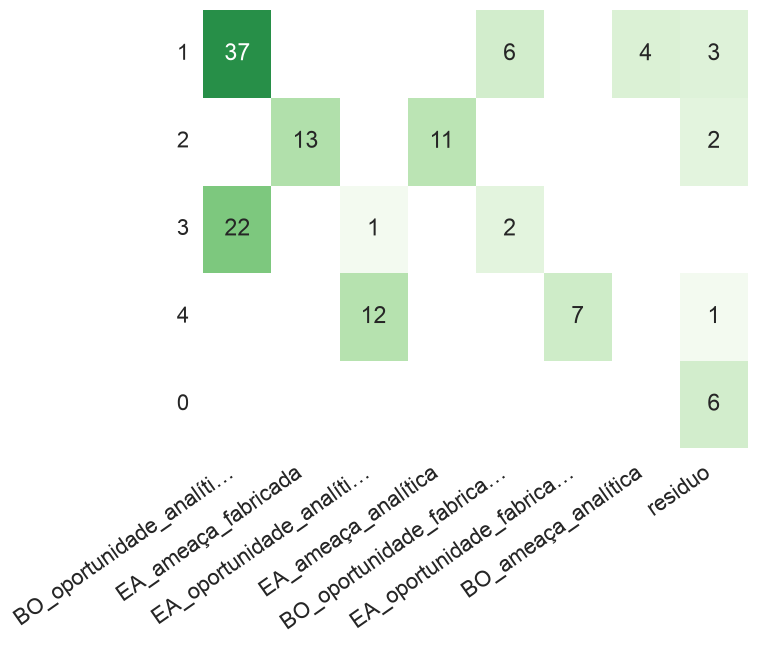

In [47]:
heatmap_2d(df4, "pam_k4", "familia_teorica")

familia_teorica,BO_oportunidade_analítica,EA_ameaça_fabricada,EA_oportunidade_analítica,EA_ameaça_analítica,BO_oportunidade_fabricada,EA_oportunidade_fabricada,BO_ameaça_analítica,residuo
fam_k4,,,,,,,,
1,59,0,0,0,8,0,0,3
2,0,13,0,11,0,0,0,2
3,0,0,13,0,0,7,0,1
0,0,0,0,0,0,0,0,6
4,0,0,0,0,0,0,4,0


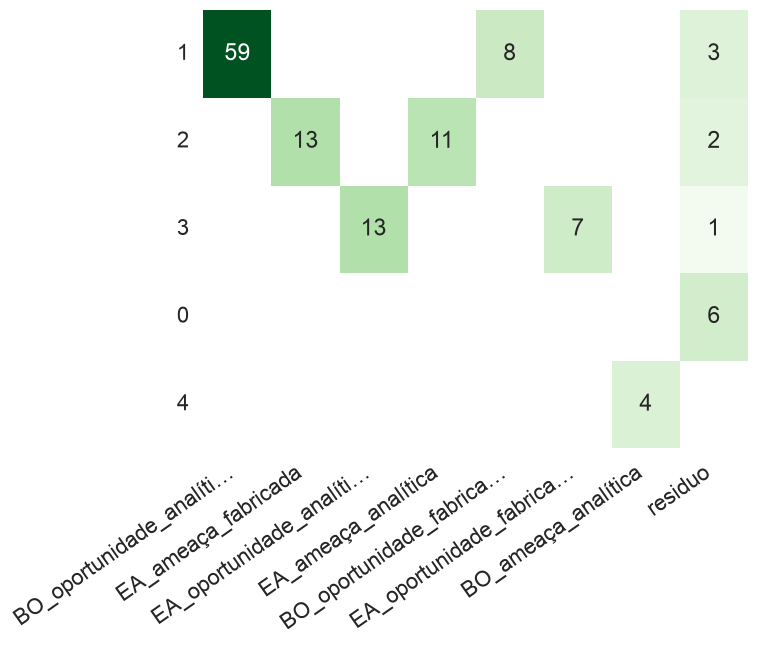

In [48]:
heatmap_2d(df3, "fam_k4", "familia_teorica")

familia_teorica,BO_oportunidade_analítica,EA_ameaça_fabricada,EA_oportunidade_analítica,EA_ameaça_analítica,BO_oportunidade_fabricada,EA_oportunidade_fabricada,BO_ameaça_analítica,residuo
fam_k7,,,,,,,,
1,59,0,0,0,8,0,0,3
2,0,0,13,0,0,7,0,1
3,0,0,0,11,0,0,0,1
4,0,7,0,0,0,0,0,0
5,0,5,0,0,0,0,0,1
0,0,0,0,0,0,0,0,6
6,0,0,0,0,0,0,4,0
7,0,1,0,0,0,0,0,0


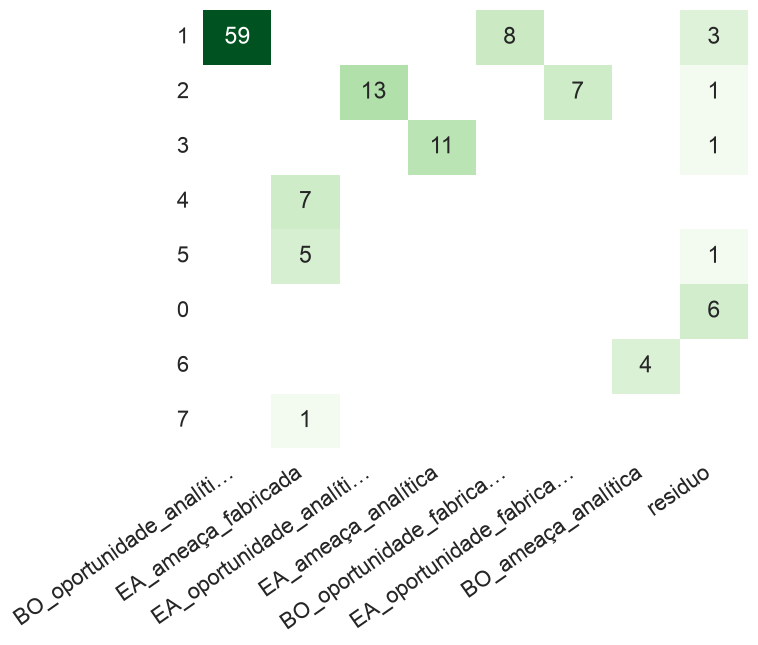

In [49]:
heatmap_2d(df3, "fam_k7", "familia_teorica")

In [50]:
1+1

2